# Notebook 05 — IG forecast (BSTS)

Fit BSTS with spike-and-slab on **IG** (LQD ETF, our proxy for IG OAS) using the full Trends predictor universe + macro controls. Inspect inclusion probabilities, component decomposition, and in-sample fit.

*Run again after the topic-only re-pull completes to pick up the 20 newly-validated topics.*


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve()))
from _helpers import project_root_from_cwd, build_full_feature_matrix, fit_bsts_default
import matplotlib.pyplot as plt
import pandas as pd
project_root_from_cwd()

PosixPath('/Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes')

## 1. Build feature matrix for IG

In [2]:
art = build_full_feature_matrix('IG', apply_target_transform=False, include_controls=True)
X, y = art['X'], art['y']
print(f'IG target series:  {len(art["target_series"]):>4d} weekly bars cached')
print(f'Trends predictors: {art["processed"].shape[1]} after quality filter')
print(f'Aligned (X, y):    X={X.shape}, y={y.shape}, range {X.index.min().date()} .. {X.index.max().date()}')
print(f'Always-included macro controls: {art["control_names"]}')
print(f'(target = LQD ETF total-return price; positive Δy = spreads tightened)')

2026-05-03 21:59:03,702 | WARNING | gtrends_bayes.features.library | dropping 1 low-quality columns (NaN frac > 0.50): ['Credit Cards']


IG target series:   957 weekly bars cached
Trends predictors: 21 after quality filter
Aligned (X, y):    X=(487, 24), y=(487,), range 2009-01-04 .. 2026-04-26
Always-included macro controls: ['vix', 'ust10y', 'ust2y10y_slope']
(target = LQD ETF total-return price; positive Δy = spreads tightened)


## 2. Fit BSTS

In [3]:
model = fit_bsts_default(y, X, niter=1500, burn=150, expected_predictors=5, seed=42)
print(model)

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


2026-05-03 21:59:04,302 | INFO    | gtrends_bayes.models.bsts | rpy2 bridge initialized; R bsts helpers loaded from /Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes/src/gtrends_bayes/models/bsts_r


2026-05-03 21:59:29,363 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_9699ef5c, niter=1500, burn=150, p=24, has_regression=True)


BSTS(n_seasons=52, expected_predictors=5, niter=1500, burn=150, seed=42, fitted=True, has_regression=True)


## 3. Posterior inclusion probabilities (top 20)

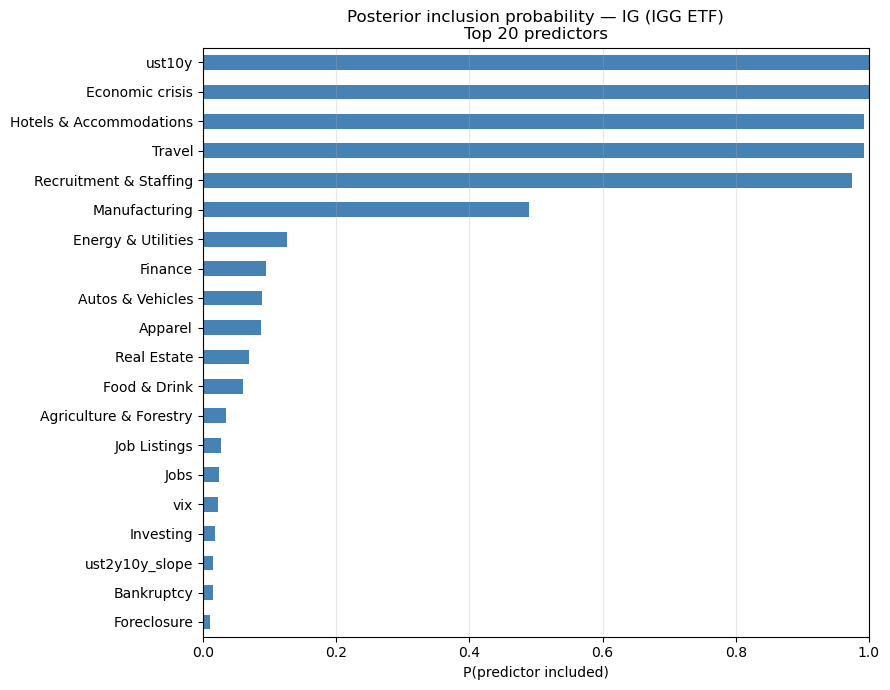

ust10y                     1.000
Economic crisis            1.000
Hotels & Accommodations    0.992
Travel                     0.992
Recruitment & Staffing     0.975
Manufacturing              0.490
Energy & Utilities         0.126
Finance                    0.094
Autos & Vehicles           0.089
Apparel                    0.087
Real Estate                0.070
Food & Drink               0.061
Agriculture & Forestry     0.034
Job Listings               0.027
Jobs                       0.024
vix                        0.022
Investing                  0.018
ust2y10y_slope             0.016
Bankruptcy                 0.015
Foreclosure                0.011
Insurance                  0.009
Home Financing             0.007
Credit & Lending           0.006
Auto Financing             0.004


In [4]:
probs = model.inclusion_probabilities()
top = probs.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
top.plot.barh(ax=ax, color='darkorange')
ax.set_title('Posterior inclusion probability — IG (LQD ETF)\nTop 20 predictors')
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('P(predictor included)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(probs.round(3).to_string())

## 4. Coefficient summary (sign + magnitude when included)

In [5]:
summary = model.coefficient_summary().round(4)
summary.head(20)

,inclusion_prob,mean_when_included,sd_when_included,sign_consistency
predictor,,,,
ust10y,1.0000,-2.7627,0.4023,1.0000
Economic crisis,1.0000,-0.2979,0.0848,1.0000
Hotels & Accommodations,0.9919,-4.7521,0.9894,1.0000
Travel,0.9919,3.5694,1.0062,1.0000
Recruitment & Staffing,0.9748,5.6323,1.1116,1.0000
Manufacturing,0.4896,-2.1731,0.7861,0.9955
Energy & Utilities,0.1259,0.9237,2.0260,0.7235
Finance,0.0941,-0.5911,1.3221,0.6850
Autos & Vehicles,0.0889,-1.1404,0.8409,0.9250


## 5. State component bands (level / trend / seasonal / regression)

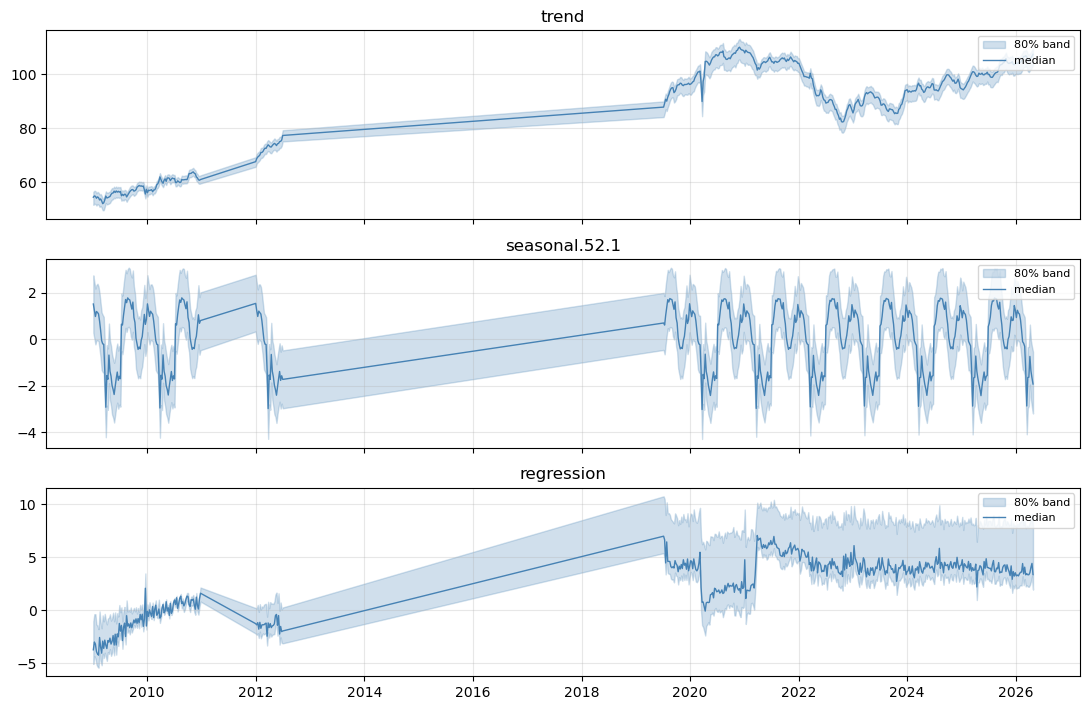

In [6]:
bands = model.component_bands(q_low=0.10, q_high=0.90)
fig, axes = plt.subplots(len(bands), 1, figsize=(11, 2.4 * len(bands)), sharex=True)
if len(bands) == 1:
    axes = [axes]
for ax, (name, df) in zip(axes, bands.items()):
    ax.fill_between(df.index, df['q_low'], df['q_high'], color='darkorange', alpha=0.25, label='80% band')
    ax.plot(df.index, df['q_med'], color='darkorange', lw=1.0, label='median')
    ax.set_title(f'{name}')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 6. In-sample fit (observed IG vs BSTS-implied)

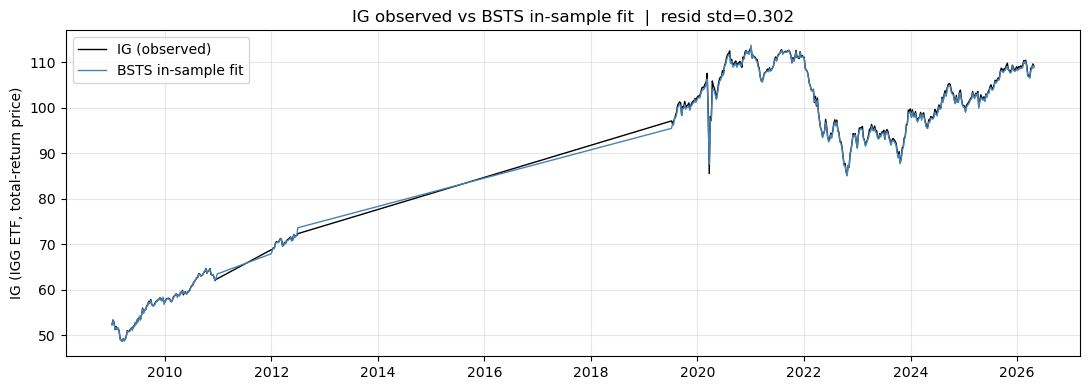

In [7]:
import numpy as np
# Sum of state contributions = BSTS in-sample fit
fit_components = sum(b['q_med'] for b in bands.values())
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y.index, y.values, color='black', lw=1.0, label='IG (observed)')
ax.plot(fit_components.index, fit_components.values, color='darkorange', lw=1.0, label='BSTS in-sample fit')
resid = y - fit_components.reindex(y.index)
ax.set_title(f'IG observed vs BSTS in-sample fit  |  resid std={resid.std():.3f}')
ax.set_ylabel('IG (LQD ETF, total-return price)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Persist artifacts so notebook 06 can load them

In [8]:
import pickle
out_dir = Path('data/processed/posterior')
out_dir.mkdir(parents=True, exist_ok=True)
artifact = {
    'target': 'IG',
    'inclusion_probs': probs,
    'coefficient_summary': summary,
    'component_bands': bands,
    'in_sample_fit_median': fit_components,
    'X_columns': list(X.columns),
    'y': y,
}
(out_dir / 'IG_bsts_v1.pkl').write_bytes(pickle.dumps(artifact))
print('wrote', out_dir / 'IG_bsts_v1.pkl')
# Free the R-side model copy.
from gtrends_bayes.models.bsts import reset_r_models
reset_r_models()
print('R-side BSTS registry cleared.')

wrote data/processed/posterior/IG_bsts_v1.pkl
R-side BSTS registry cleared.
